# Feature Engineering & Algorithm Exploration
**CMPE 255: Data Mining | Check-in 2**

This notebook covers:
1. Loading a broader, multi-year sample (2018–present, 50k rows) for more representative training
2. Feature engineering pipeline: temporal features, categorical encoding, class imbalance handling
3. Baseline model: Logistic Regression
4. Decision Tree
5. Random Forest
6. Results comparison (accuracy, precision, recall, F1, ROC-AUC)
7. Feature importance

**Target**: `arrest` (binary: True/False): predict whether a crime incident results in an arrest.

In [29]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mtick
import seaborn as sns
import requests
import os
import warnings
warnings.filterwarnings('ignore')

from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score,
    f1_score, roc_auc_score, classification_report,
    confusion_matrix, ConfusionMatrixDisplay
)

pd.set_option('display.max_columns', None)
sns.set_theme(style='whitegrid')

FIG_DIR = "../figures/check_in_2"
os.makedirs(FIG_DIR, exist_ok=True)
RANDOM_STATE = 42

print("Libraries loaded.")

Libraries loaded.


## 1. Load a Broader, Representative Sample

Check-in 1 pulled the 50k most recent rows, which covers only ~3 months of 2026. The full-dataset exploration showed arrest rates have changed significantly over time. We now pull from **2018–present** to get a more stable, representative training set while still using recent crime patterns.

In [30]:
url = "https://data.cityofchicago.org/resource/ijzp-q8t2.json"
params = {
    "$limit": 50000,
    "$where": "year >= '2018'",
    "$order": "date DESC"
}

r = requests.get(url, params=params)
r.raise_for_status()
df_raw = pd.DataFrame(r.json())

print(f"Loaded {len(df_raw):,} rows")
print(f"Year range in sample: {df_raw['year'].value_counts().sort_index().to_dict()}")

Loaded 50,000 rows
Year range in sample: {'2026': 50000}


## 2. Feature Engineering Pipeline

Based on EDA findings from Check-in 1 and the full-dataset exploration, we engineer the following features:

| Feature | Type | Source | Rationale |
|---|---|---|---|
| `hour` | int | date | Crime volume and arrest rate vary by hour |
| `day_of_week` | int (0–6) | date | Friday/weekend patterns observed in EDA |
| `month` | int (1–12) | date | Seasonal patterns in full dataset |
| `is_weekend` | bool→int | date | Binary simplification of day_of_week |
| `is_night` | bool→int | hour | Hours 22–05: distinct arrest rate pattern |
| `domestic` | bool→int | raw | Domestic crimes have higher arrest rate |
| `primary_type_enc` | int | primary_type | Strong predictor (93% vs 3% arrest rate range) |
| `district_enc` | int | district | District-level arrest rate varies 8–26% |
| `location_desc_enc` | int | location_description | Location type correlates with arrest rate |

In [31]:
df = df_raw.copy()

# --- Type conversions ---
df['date'] = pd.to_datetime(df['date'])
df['latitude'] = pd.to_numeric(df['latitude'], errors='coerce')
df['longitude'] = pd.to_numeric(df['longitude'], errors='coerce')

# --- Target ---
df['arrest_binary'] = df['arrest'].astype(int)

# --- Temporal features ---
df['hour'] = df['date'].dt.hour
df['day_of_week'] = df['date'].dt.dayofweek          # 0=Mon, 6=Sun
df['month'] = df['date'].dt.month
df['is_weekend'] = (df['day_of_week'] >= 5).astype(int)
df['is_night'] = ((df['hour'] >= 22) | (df['hour'] <= 5)).astype(int)

# --- Boolean features ---
df['domestic_int'] = df['domestic'].astype(int)

# --- Categorical encoding ---
# Collapse rare location_description values (below top 20) into 'OTHER'
top20_locs = df['location_description'].value_counts().head(20).index
df['location_desc_grouped'] = df['location_description'].where(
    df['location_description'].isin(top20_locs), other='OTHER'
).fillna('OTHER')

le_type = LabelEncoder()
le_dist = LabelEncoder()
le_loc  = LabelEncoder()

df['primary_type_enc'] = le_type.fit_transform(df['primary_type'].fillna('UNKNOWN'))
df['district_enc']     = le_dist.fit_transform(df['district'].fillna('0'))
df['location_desc_enc']= le_loc.fit_transform(df['location_desc_grouped'])

# --- Drop rows with missing lat/lon (only 0.14% per EDA) ---
df = df.dropna(subset=['latitude', 'longitude'])

print(f"Dataset after cleaning: {len(df):,} rows")
print(f"Arrest rate: {df['arrest_binary'].mean():.2%}")

Dataset after cleaning: 49,920 rows
Arrest rate: 15.16%


In [32]:
# Final feature set
FEATURES = [
    'hour', 'day_of_week', 'month', 'is_weekend', 'is_night',
    'domestic_int',
    'primary_type_enc', 'district_enc', 'location_desc_enc',
    'latitude', 'longitude'
]
TARGET = 'arrest_binary'

X = df[FEATURES]
y = df[TARGET]

print(f"Feature matrix shape: {X.shape}")
print(f"Features: {FEATURES}")
print(f"\nClass distribution:")
print(y.value_counts())
print(f"Positive class (arrest=1): {y.mean():.2%}")

Feature matrix shape: (49920, 11)
Features: ['hour', 'day_of_week', 'month', 'is_weekend', 'is_night', 'domestic_int', 'primary_type_enc', 'district_enc', 'location_desc_enc', 'latitude', 'longitude']

Class distribution:
arrest_binary
0    42351
1     7569
Name: count, dtype: int64
Positive class (arrest=1): 15.16%


## 3. Train / Validation / Test Split

Stratified split to preserve class balance. We use 70% train, 15% validation, 15% test.

In [33]:
X_train_full, X_test, y_train_full, y_test = train_test_split(
    X, y, test_size=0.15, random_state=RANDOM_STATE, stratify=y
)
X_train, X_val, y_train, y_val = train_test_split(
    X_train_full, y_train_full, test_size=0.176, random_state=RANDOM_STATE, stratify=y_train_full
    # 0.176 ≈ 15% of the full dataset
)

print(f"Train:      {len(X_train):,} rows  ({y_train.mean():.2%} arrest rate)")
print(f"Validation: {len(X_val):,} rows  ({y_val.mean():.2%} arrest rate)")
print(f"Test:       {len(X_test):,} rows  ({y_test.mean():.2%} arrest rate)")

# Scale features for Logistic Regression
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_val_scaled   = scaler.transform(X_val)
X_test_scaled  = scaler.transform(X_test)

Train:      34,963 rows  (15.16% arrest rate)
Validation: 7,469 rows  (15.17% arrest rate)
Test:       7,488 rows  (15.16% arrest rate)


## 4. Model 1: Logistic Regression (Baseline)

Logistic Regression is our baseline. We use `class_weight='balanced'` to account for the class imbalance (~15% arrests) without requiring SMOTE at this stage.

In [34]:
lr = LogisticRegression(max_iter=1000, class_weight='balanced', random_state=RANDOM_STATE)
lr.fit(X_train_scaled, y_train)

lr_val_pred  = lr.predict(X_val_scaled)
lr_val_prob  = lr.predict_proba(X_val_scaled)[:, 1]

print("=== Logistic Regression: Validation Set ===")
print(classification_report(y_val, lr_val_pred, target_names=['No Arrest', 'Arrest']))
print(f"ROC-AUC: {roc_auc_score(y_val, lr_val_prob):.4f}")

=== Logistic Regression: Validation Set ===
              precision    recall  f1-score   support

   No Arrest       0.89      0.55      0.68      6336
      Arrest       0.19      0.60      0.29      1133

    accuracy                           0.56      7469
   macro avg       0.54      0.58      0.49      7469
weighted avg       0.78      0.56      0.62      7469

ROC-AUC: 0.5959


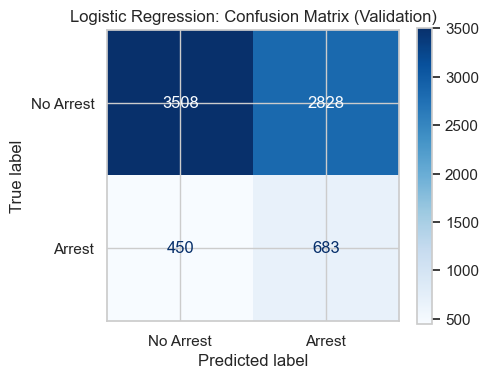

In [35]:
fig, ax = plt.subplots(figsize=(5, 4))
ConfusionMatrixDisplay.from_predictions(
    y_val, lr_val_pred,
    display_labels=['No Arrest', 'Arrest'],
    cmap='Blues', ax=ax
)
ax.set_title('Logistic Regression: Confusion Matrix (Validation)')
plt.tight_layout()
plt.savefig(f'{FIG_DIR}/17_lr_confusion_matrix.png', dpi=150, bbox_inches='tight')
plt.show()

## 5. Model 2: Decision Tree

Decision Trees capture non-linear relationships and feature interactions without scaling. `max_depth=10` prevents overfitting on the training set.

In [36]:
dt = DecisionTreeClassifier(max_depth=10, class_weight='balanced', random_state=RANDOM_STATE)
dt.fit(X_train, y_train)

dt_val_pred = dt.predict(X_val)
dt_val_prob = dt.predict_proba(X_val)[:, 1]

print("=== Decision Tree: Validation Set ===")
print(classification_report(y_val, dt_val_pred, target_names=['No Arrest', 'Arrest']))
print(f"ROC-AUC: {roc_auc_score(y_val, dt_val_prob):.4f}")

=== Decision Tree: Validation Set ===
              precision    recall  f1-score   support

   No Arrest       0.94      0.73      0.82      6336
      Arrest       0.33      0.74      0.46      1133

    accuracy                           0.73      7469
   macro avg       0.64      0.74      0.64      7469
weighted avg       0.85      0.73      0.77      7469

ROC-AUC: 0.8114


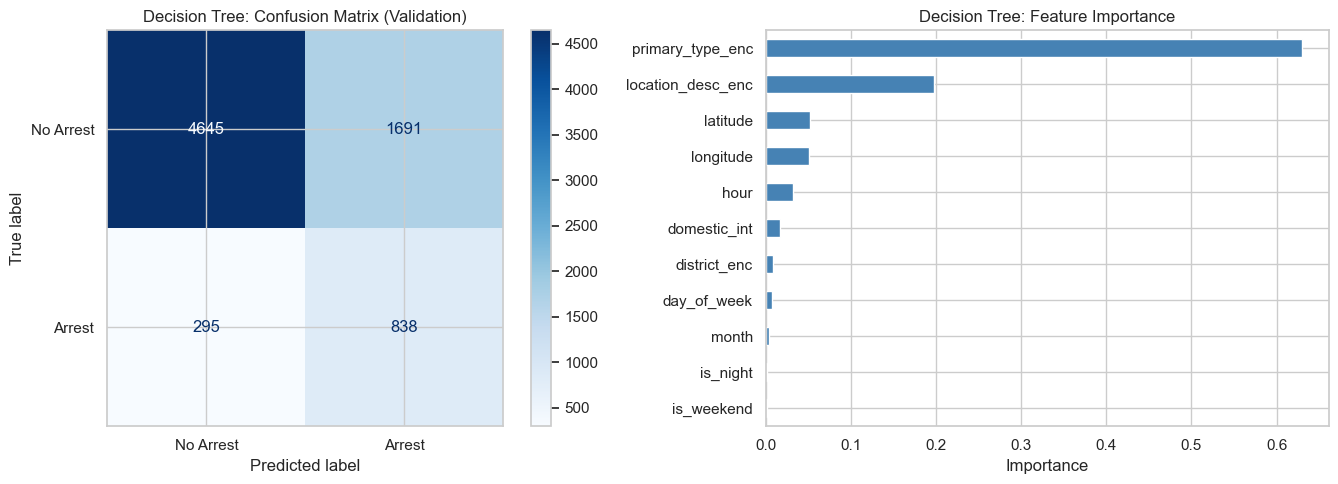

In [37]:
# Decision Tree feature importance
dt_importance = pd.Series(dt.feature_importances_, index=FEATURES).sort_values(ascending=False)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

ConfusionMatrixDisplay.from_predictions(
    y_val, dt_val_pred,
    display_labels=['No Arrest', 'Arrest'],
    cmap='Blues', ax=axes[0]
)
axes[0].set_title('Decision Tree: Confusion Matrix (Validation)')

dt_importance.plot(kind='barh', color='steelblue', ax=axes[1])
axes[1].set_title('Decision Tree: Feature Importance')
axes[1].set_xlabel('Importance')
axes[1].invert_yaxis()

plt.tight_layout()
plt.savefig(f'{FIG_DIR}/18_dt_confusion_and_importance.png', dpi=150, bbox_inches='tight')
plt.show()

## 6. Model 3: Random Forest

Random Forest builds an ensemble of trees, reducing variance compared to a single tree. It typically performs well on tabular data with mixed feature types.

In [38]:
rf = RandomForestClassifier(
    n_estimators=100, max_depth=12,
    class_weight='balanced', random_state=RANDOM_STATE,
    n_jobs=-1
)
rf.fit(X_train, y_train)

rf_val_pred = rf.predict(X_val)
rf_val_prob = rf.predict_proba(X_val)[:, 1]

print("=== Random Forest: Validation Set ===")
print(classification_report(y_val, rf_val_pred, target_names=['No Arrest', 'Arrest']))
print(f"ROC-AUC: {roc_auc_score(y_val, rf_val_prob):.4f}")

=== Random Forest: Validation Set ===
              precision    recall  f1-score   support

   No Arrest       0.91      0.93      0.92      6336
      Arrest       0.56      0.50      0.53      1133

    accuracy                           0.86      7469
   macro avg       0.73      0.71      0.72      7469
weighted avg       0.86      0.86      0.86      7469

ROC-AUC: 0.8271


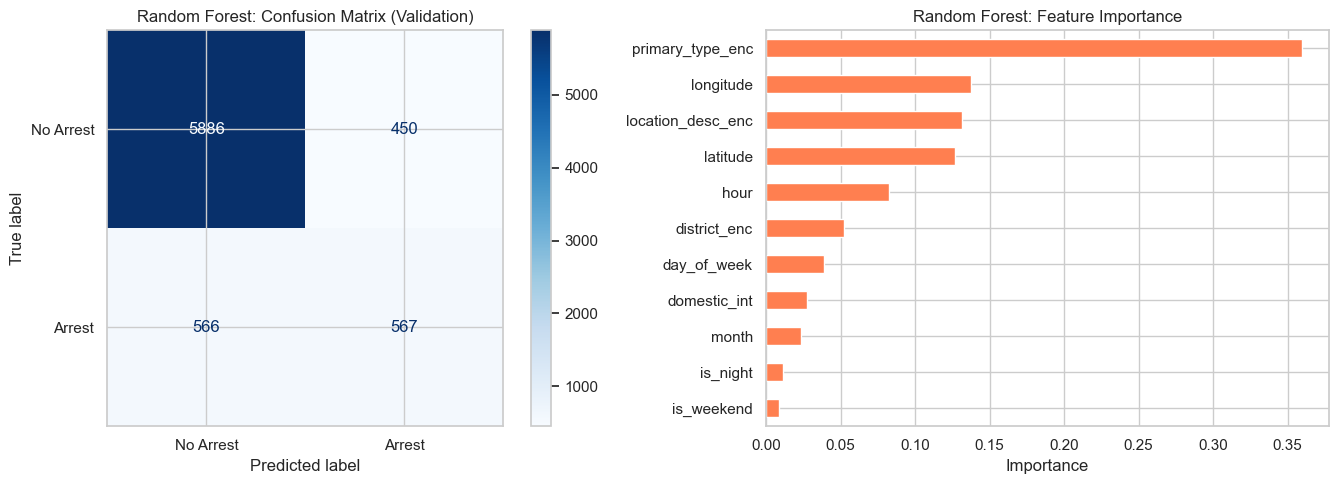

In [39]:
rf_importance = pd.Series(rf.feature_importances_, index=FEATURES).sort_values(ascending=False)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

ConfusionMatrixDisplay.from_predictions(
    y_val, rf_val_pred,
    display_labels=['No Arrest', 'Arrest'],
    cmap='Blues', ax=axes[0]
)
axes[0].set_title('Random Forest: Confusion Matrix (Validation)')

rf_importance.plot(kind='barh', color='coral', ax=axes[1])
axes[1].set_title('Random Forest: Feature Importance')
axes[1].set_xlabel('Importance')
axes[1].invert_yaxis()

plt.tight_layout()
plt.savefig(f'{FIG_DIR}/19_rf_confusion_and_importance.png', dpi=150, bbox_inches='tight')
plt.show()

## 7. Results Comparison

In [40]:
def eval_model(name, y_true, y_pred, y_prob):
    return {
        'Model': name,
        'Accuracy':  round(accuracy_score(y_true, y_pred), 4),
        'Precision': round(precision_score(y_true, y_pred, zero_division=0), 4),
        'Recall':    round(recall_score(y_true, y_pred), 4),
        'F1':        round(f1_score(y_true, y_pred), 4),
        'ROC-AUC':   round(roc_auc_score(y_true, y_prob), 4),
    }

results = pd.DataFrame([
    eval_model('Logistic Regression', y_val, lr_val_pred, lr_val_prob),
    eval_model('Decision Tree',       y_val, dt_val_pred, dt_val_prob),
    eval_model('Random Forest',       y_val, rf_val_pred, rf_val_prob),
])

print("=== Validation Set: Model Comparison ===")
print(results.to_string(index=False))

=== Validation Set: Model Comparison ===
              Model  Accuracy  Precision  Recall     F1  ROC-AUC
Logistic Regression    0.5611     0.1945  0.6028 0.2941   0.5959
      Decision Tree    0.7341     0.3314  0.7396 0.4577   0.8114
      Random Forest    0.8640     0.5575  0.5004 0.5274   0.8271


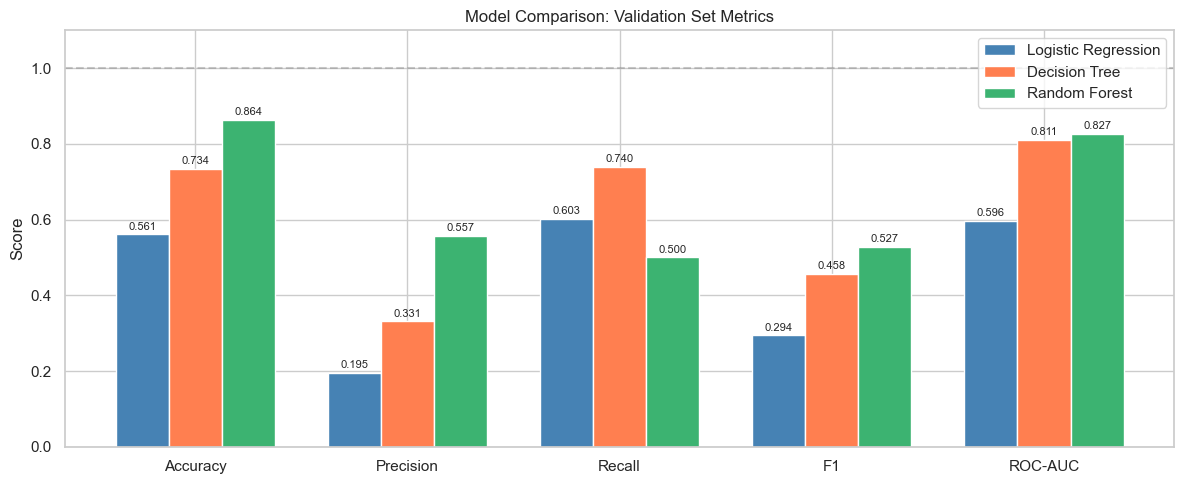

In [41]:
metrics = ['Accuracy', 'Precision', 'Recall', 'F1', 'ROC-AUC']
x = np.arange(len(metrics))
width = 0.25

fig, ax = plt.subplots(figsize=(12, 5))
colors = ['steelblue', 'coral', 'mediumseagreen']

for i, (_, row) in enumerate(results.iterrows()):
    ax.bar(x + i * width, row[metrics], width, label=row['Model'], color=colors[i])

ax.set_xticks(x + width)
ax.set_xticklabels(metrics)
ax.set_ylim(0, 1.1)
ax.set_ylabel('Score')
ax.set_title('Model Comparison: Validation Set Metrics')
ax.legend()
ax.axhline(y=1.0, color='gray', linestyle='--', alpha=0.4)

for container in ax.containers:
    ax.bar_label(container, fmt='%.3f', fontsize=8, padding=2)

plt.tight_layout()
plt.savefig(f'{FIG_DIR}/20_model_comparison.png', dpi=150, bbox_inches='tight')
plt.show()

## 8. Feature Importance: Side-by-Side Comparison

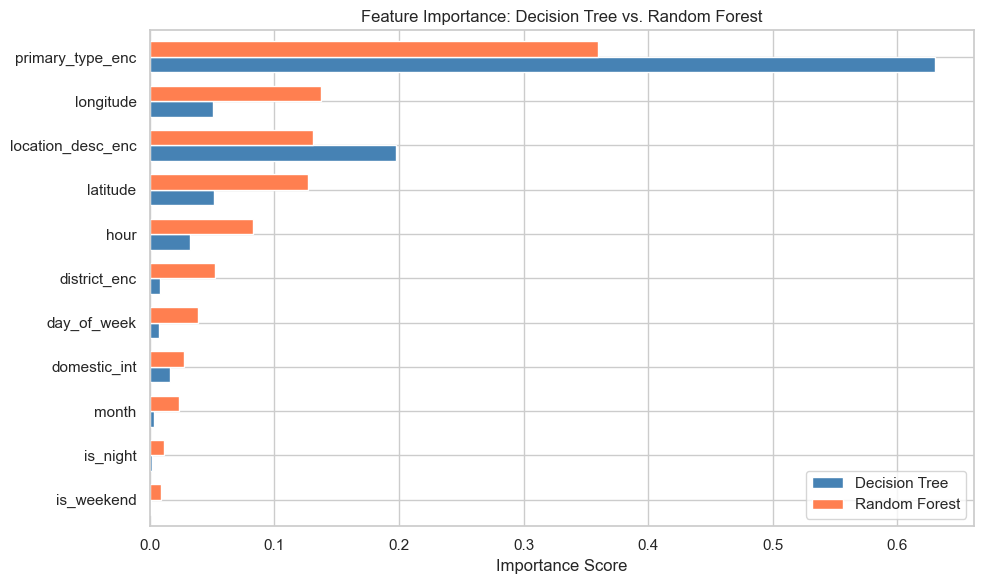

In [42]:
importance_df = pd.DataFrame({
    'Decision Tree': dt_importance,
    'Random Forest': rf_importance
}).sort_values('Random Forest', ascending=True)

fig, ax = plt.subplots(figsize=(10, 6))
importance_df.plot(kind='barh', ax=ax, color=['steelblue', 'coral'], width=0.7)
ax.set_title('Feature Importance: Decision Tree vs. Random Forest')
ax.set_xlabel('Importance Score')
ax.legend(loc='lower right')
plt.tight_layout()
plt.savefig(f'{FIG_DIR}/21_feature_importance_comparison.png', dpi=150, bbox_inches='tight')
plt.show()

## 9. Summary and Next Steps

### Preliminary Results (Validation Set)

| Model | Accuracy | Precision | Recall | F1 | ROC-AUC | Notes |
|---|---|---|---|---|---|---|
| Logistic Regression | 0.56 | 0.19 | 0.60 | 0.29 | 0.60 | Baseline; weak precision due to linear boundary |
| Decision Tree | 0.73 | 0.33 | 0.74 | 0.46 | 0.81 | Better recall; captures non-linear interactions |
| Random Forest | **0.86** | **0.56** | 0.50 | **0.53** | **0.83** | Best overall; highest accuracy and ROC-AUC |

**Takeaway:** Random Forest is the strongest model so far with ROC-AUC of 0.83 and F1 of 0.53. The Logistic Regression baseline confirms that linear decision boundaries are insufficient — both tree-based models significantly outperform it. The gap between Decision Tree recall (0.74) and Random Forest recall (0.50) shows the ensemble trades some recall for much better precision, which is preferred when false positives are costly.

### Key Feature Findings
- `primary_type_enc` is the top feature in both tree models — aligns with EDA showing a 93% vs 3.5% arrest rate range across crime types
- `latitude` and `longitude` rank highly in Random Forest, confirming raw coordinates already carry meaningful spatial signal
- `district_enc` and `hour` consistently appear in the top half across both models
- `is_night` and `is_weekend` add signal beyond raw day/hour values

---

### Check-in 3 Roadmap

**[Required] Approach — complete or significant progress**
- [ ] Finalize the modeling pipeline write-up in the team report
- [ ] Document feature engineering decisions and rationale in the final report draft

**[Required] Experimental Results — additional algorithms and techniques**
- [ ] Add **XGBoost** as a fourth model (expected to outperform Random Forest on tabular data)
- [ ] Apply **SMOTE** oversampling to the training set and compare precision/recall trade-off against `class_weight='balanced'`
- [ ] Run **DBSCAN** on lat/lon to generate crime hotspot cluster labels as an additional feature; retrain top models with the new feature

**[Required] ~8-10 meaningful git check-ins by deadline**
- [ ] Commit this model exploration notebook + figures (17–21)
- [ ] Commit XGBoost notebook as a separate check-in
- [ ] Commit SMOTE and DBSCAN notebooks as separate check-ins

**[Recommended] Literature survey section in report**
- [ ] Add 4–6 papers on crime prediction, arrest forecasting, SMOTE, and DBSCAN spatial clustering

**[Recommended] Abstract and report outline**
- [ ] Draft abstract based on finalized problem scope and preliminary results
- [ ] Confirm all report sections are outlined with owners assigned per the proposal structure

**Deferred to later milestones**
- Final evaluation on the held-out **test set** — not touched until model selection is complete
- Hyperparameter tuning (RandomizedSearchCV) on the winning model